In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Boyut:", df.shape)

print("\nSütunlar:")
print(df.columns.tolist())

print("\nEksik Değerler:")
print(df.isnull().sum())

Boyut: (891, 12)

Sütunlar:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Eksik Değerler:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Titanic Veri Seti Analizi

## Özet

Bu çalışmada Titanic yolcularına ait veri seti kullanılarak tanımlayıcı istatistikler ve veri görselleştirme yöntemleri uygulanmıştır. Veri seti 891 gözlem ve 12 değişkenden oluşmaktadır. Analiz kapsamında yaş, cinsiyet, yolcu sınıfı, bilet ücreti ve hayatta kalma durumu gibi değişkenler incelenmiştir.

## Veri Seti Hakkında

Veri seti Titanic gemisinde bulunan yolculara ait demografik ve seyahat bilgilerini içermektedir. Veri setinde yaş, cinsiyet, yolcu sınıfı, bilet ücreti ve hayatta kalma durumu gibi değişkenler bulunmaktadır.

Veri seti boyutu: 891 satır, 12 sütun.

Eksik değer bulunan değişkenler:
- Age: 177 eksik değer
- Cabin: 687 eksik değer
- Embarked: 2 eksik değer

In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Tanımsal İstatistikler

Sayısal değişkenlerin özet istatistikleri incelendiğinde yaş değişkeninin ortalamasının yaklaşık 29 yıl olduğu görülmektedir. Bilet ücretlerinde ise yüksek değişkenlik bulunmaktadır. Bu durum veri setinde farklı ekonomik seviyelerden yolcuların bulunduğunu göstermektedir.

In [9]:
df["Age"].mean()

np.float64(29.69911764705882)

In [6]:
df["Age"].median()

np.float64(28.0)

In [7]:
df["Age"].std()

np.float64(14.526497332334042)

In [8]:
df.select_dtypes(include="number").corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## İstatistiksel Bulgular

Titanic veri seti üzerinde yapılan analiz sonucunda yolcuların ortalama yaşının yaklaşık 29,7 olduğu belirlenmiştir. Medyan yaş değeri 28 olarak hesaplanmıştır. Yaş değişkeninin standart sapması yaklaşık 14,53 olup yaşların geniş bir aralıkta dağıldığını göstermektedir.

Korelasyon analizi sonucunda yolcu sınıfı (Pclass) ile bilet ücreti (Fare) arasında negatif yönlü ilişki görülmüştür. Ayrıca hayatta kalma durumu ile bilet ücreti arasında zayıf pozitif ilişki bulunmaktadır.

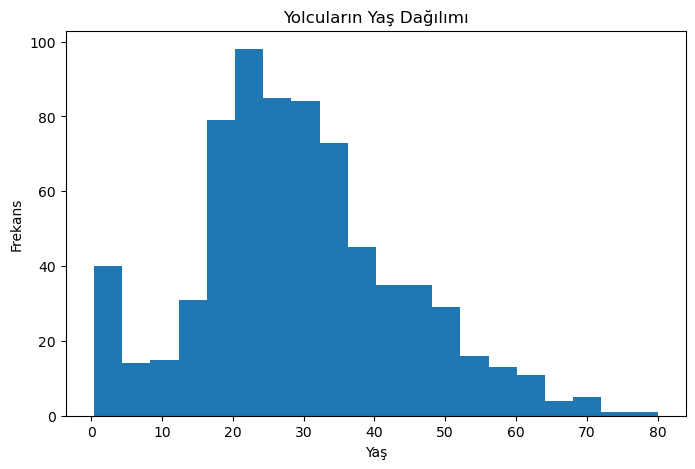

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Age"].dropna(), bins=20)

plt.title("Yolcuların Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Frekans")

plt.show()

### Grafik 1: Yaş Dağılımı

Yorum: Histogram incelendiğinde yolcuların büyük bölümünün 20–40 yaş aralığında toplandığı görülmektedir. Veri setinde çocuk ve ileri yaş grubundaki yolcular da yer almakla birlikte frekansın en yüksek olduğu yaş aralığı genç yetişkinlerdir.

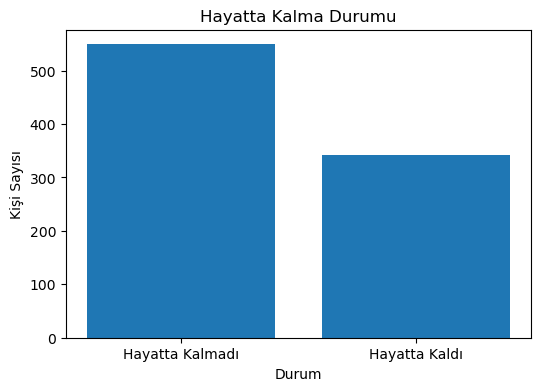

In [12]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Hayatta Kalmadı", "Hayatta Kaldı"], survival_counts)

plt.title("Hayatta Kalma Durumu")
plt.xlabel("Durum")
plt.ylabel("Kişi Sayısı")

plt.show()

### Grafik 2: Hayatta Kalma Durumu

Yorum: Titanic kazasında hayatta kalamayan yolcu sayısının hayatta kalan yolcu sayısından fazla olduğu görülmektedir.

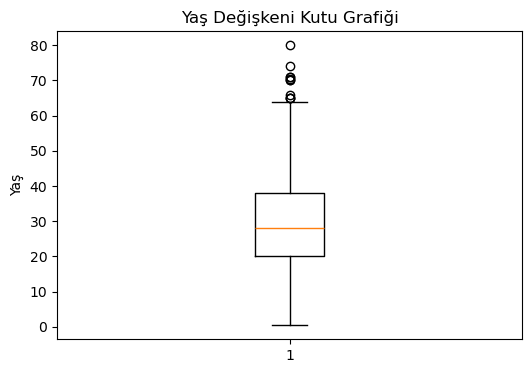

In [14]:
plt.figure(figsize=(6,4))

plt.boxplot(df["Age"].dropna())

plt.title("Yaş Değişkeni Kutu Grafiği")
plt.ylabel("Yaş")

plt.show()

### Grafik 3: Yaş Değişkeni Kutu Grafiği

Yorum: Kutu grafiği incelendiğinde yaş değişkeninde aykırı gözlemler bulunduğu görülmektedir. Yolcuların büyük bölümü belirli yaş aralıklarında yoğunlaşmaktadır.

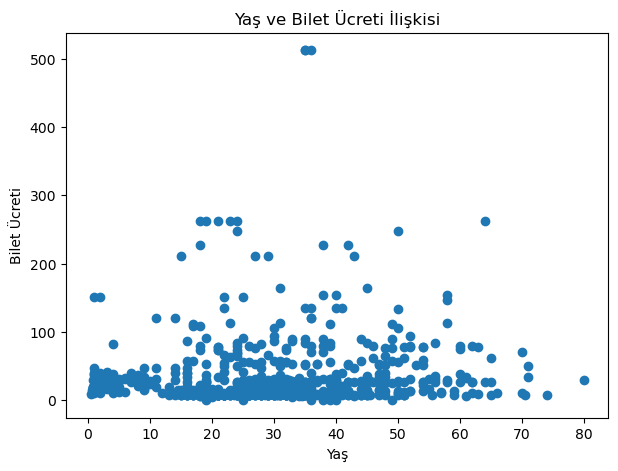

In [15]:
plt.figure(figsize=(7,5))

plt.scatter(df["Age"], df["Fare"])

plt.title("Yaş ve Bilet Ücreti İlişkisi")
plt.xlabel("Yaş")
plt.ylabel("Bilet Ücreti")

plt.show()

### Grafik 4: Yaş ve Bilet Ücreti İlişkisi

Yorum: Saçılım grafiği incelendiğinde yaş ile bilet ücreti arasında belirgin bir doğrusal ilişki görülmemektedir. Farklı yaş gruplarında farklı bilet ücretleri bulunduğu gözlenmektedir.

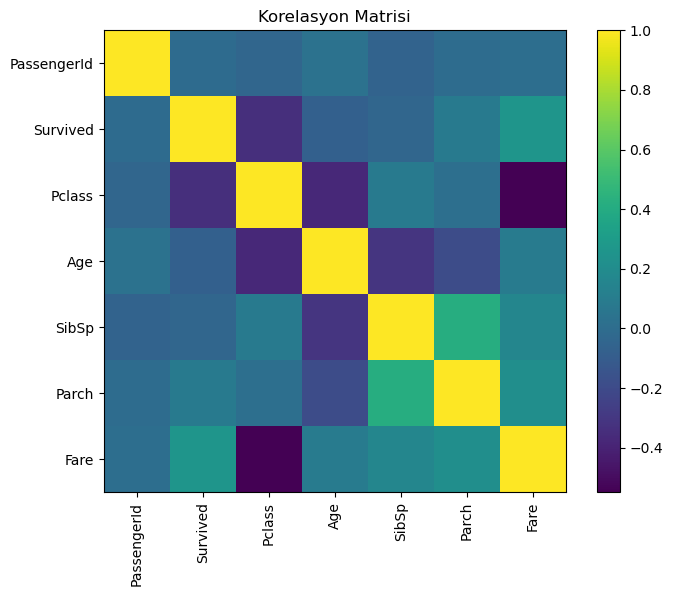

In [16]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include="number").corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Korelasyon Matrisi")

plt.show()

### Grafik 5: Korelasyon Matrisi

Yorum: Korelasyon matrisi incelendiğinde yolcu sınıfı (Pclass) ile bilet ücreti (Fare) arasında negatif yönlü ilişki görülmektedir. Hayatta kalma durumu ile bilet ücreti arasında ise zayıf pozitif ilişki bulunmaktadır.

## Bulgular

1. Titanic veri setinde yolcuların yaş ortalaması yaklaşık 29,7 olarak hesaplanmıştır. Medyan yaşın 28 olması, yolcuların büyük bölümünün genç yetişkin yaş grubunda toplandığını göstermektedir.

2. Hayatta kalma durumu incelendiğinde, hayatta kalamayan yolcu sayısının hayatta kalan yolcu sayısından daha fazla olduğu görülmektedir.

3. Korelasyon analizine göre yolcu sınıfı (Pclass) ile bilet ücreti (Fare) arasında negatif yönlü ilişki bulunmaktadır. Bu durum, yolcu sınıfı değiştikçe bilet ücretinin de belirgin biçimde farklılaştığını göstermektedir.

## Sonuç

Titanic veri seti üzerinde gerçekleştirilen analizlerde yolcuların yaş dağılımı, hayatta kalma durumu ve bilet ücretleri incelenmiştir. Yolcuların yaş ortalamasının yaklaşık 29,7 olduğu belirlenmiştir. Korelasyon analizinde yolcu sınıfı ile bilet ücreti arasında negatif yönlü ilişki gözlenmiştir. Grafiksel analizler sonucunda yolcuların büyük bölümünün genç yetişkin yaş grubunda olduğu ve hayatta kalamayan yolcu sayısının daha fazla olduğu görülmüştür. Elde edilen bulgular veri setinin genel yapısını anlamaya katkı sağlamaktadır.